In [4]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

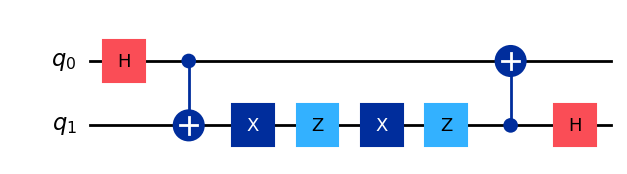

In [7]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing
pass

# For 01, apply X to qubit 1
sdc.x(1)

# For 10, apply Z to qubit 1
sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [8]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

{'10': 1024}


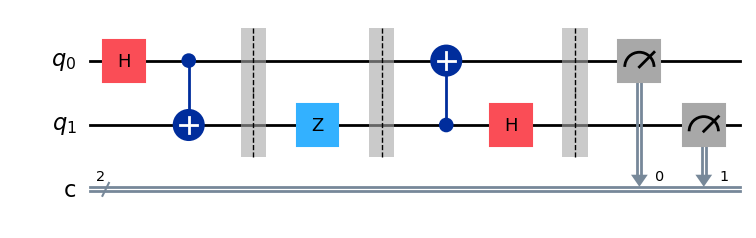

In [5]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

msg = "10"   # choose one: "00", "01", "10", "11"

sdc = QuantumCircuit(2, 2)

# Create Bell pair
sdc.h(0)
sdc.cx(0, 1)
sdc.barrier()

# Alice encodes on qubit 1
if msg == "00":
    pass
elif msg == "01":
    sdc.x(1)
elif msg == "10":
    sdc.z(1)
elif msg == "11":
    sdc.x(1)
    sdc.z(1)

sdc.barrier()

# Bob decodes
sdc.cx(1, 0)
sdc.h(1)
sdc.barrier()

# Measure both qubits
sdc.measure([0, 1], [0, 1])

# Simulate
sim = AerSimulator()
compiled = transpile(sdc, sim)
result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)
sdc.draw("mpl")


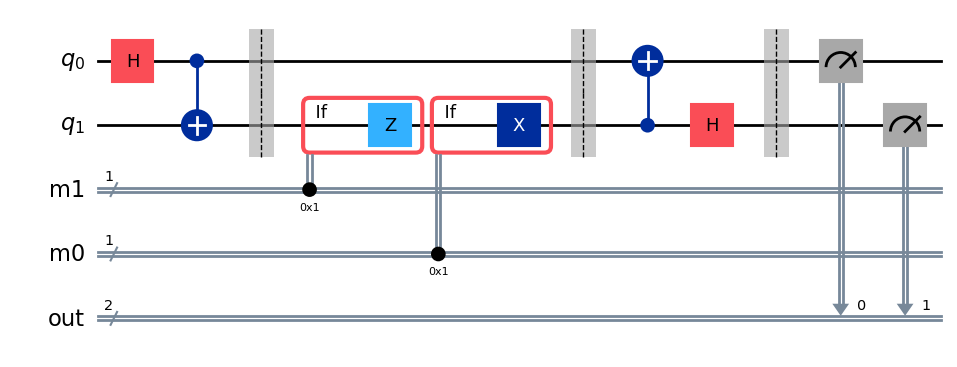

In [9]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# Qubits
q = QuantumRegister(2, "q")

# Classical bits
# m1 is the first bit (0 or 1) -> controls Z
# m0 is the second bit (0 or 1) -> controls X
m1 = ClassicalRegister(1, "m1")
m0 = ClassicalRegister(1, "m0")

# Output for readings
out = ClassicalRegister(2, "out")

# Build the circuit
sdc = QuantumCircuit(q, m1, m0, out)

# Step 1: Create Bell pair on q[0] and q[1]
sdc.h(q[0])
sdc.cx(q[0], q[1])
sdc.barrier()

# Step 2: Alice encodes using the two classical bits
# If m1 is 1, apply Z on q[1]
with sdc.if_test((m1, 1)):
    sdc.z(q[1])

# If m0 is 1, apply X on q[1]
with sdc.if_test((m0, 1)):
    sdc.x(q[1])

sdc.barrier()

# Step 3: Bob decodes
sdc.cx(q[1], q[0])
sdc.h(q[1])
sdc.barrier()

# Step 4: Measure both qubits
sdc.measure(q[0], out[0])
sdc.measure(q[1], out[1])

# Draw the circuit
sdc.draw("mpl")